In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

funds = pd.read_csv("../data/raw/01_fund_master.csv")
nav = pd.read_csv("../data/processed/02_nav_history_cleaned.csv")
sip = pd.read_csv("../data/raw/04_monthly_sip_inflows.csv")
aum = pd.read_csv("../data/raw/03_aum_by_fund_house.csv")
transactions = pd.read_csv("../data/processed/transaction_cleaned.csv")
performance = pd.read_csv("../data/processed/clean_performance.csv")

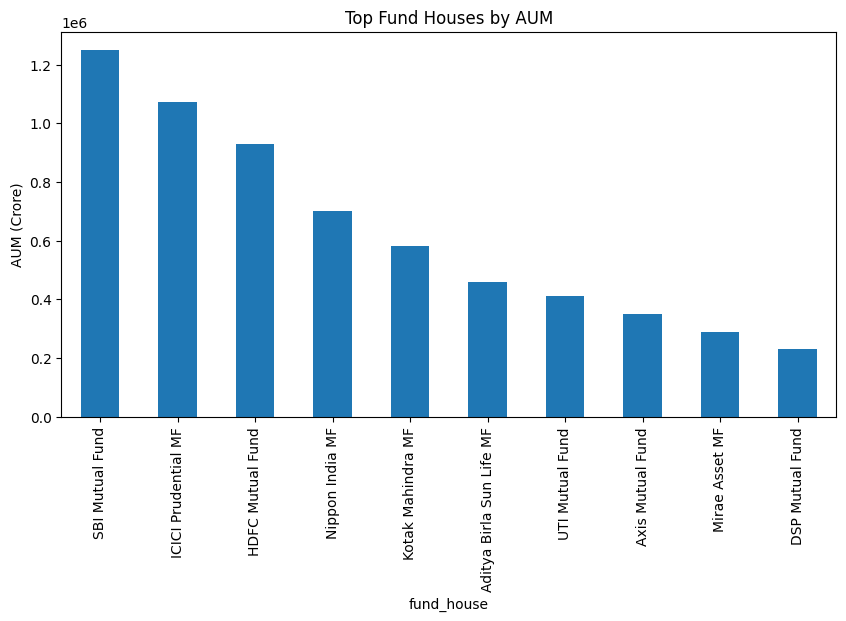

In [5]:
top_aum = aum.groupby("fund_house")["aum_crore"].max()
top_aum = top_aum.sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
top_aum.plot(kind="bar")
plt.title("Top Fund Houses by AUM")
plt.ylabel("AUM (Crore)")
plt.show()

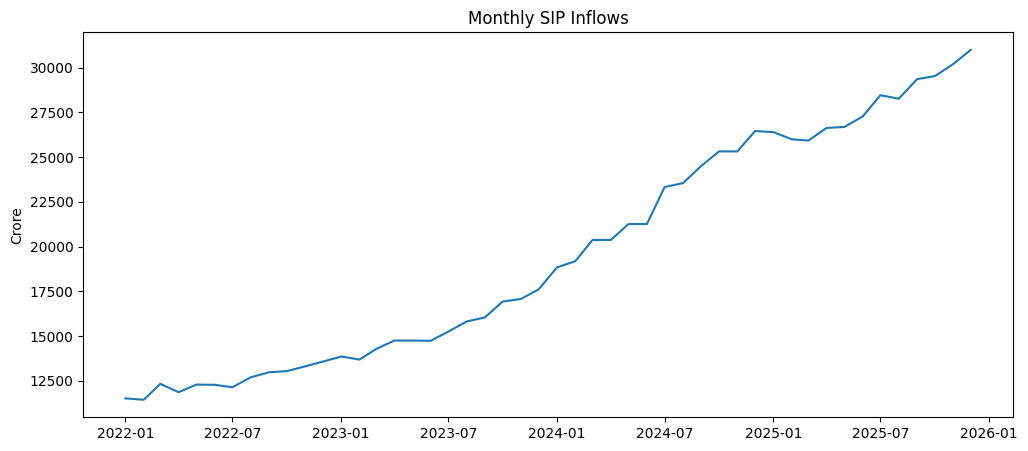

In [6]:
sip["month"] = pd.to_datetime(sip["month"])

plt.figure(figsize=(12,5))
plt.plot(sip["month"], sip["sip_inflow_crore"])
plt.title("Monthly SIP Inflows")
plt.ylabel("Crore")
plt.show()

<Axes: xlabel='category'>

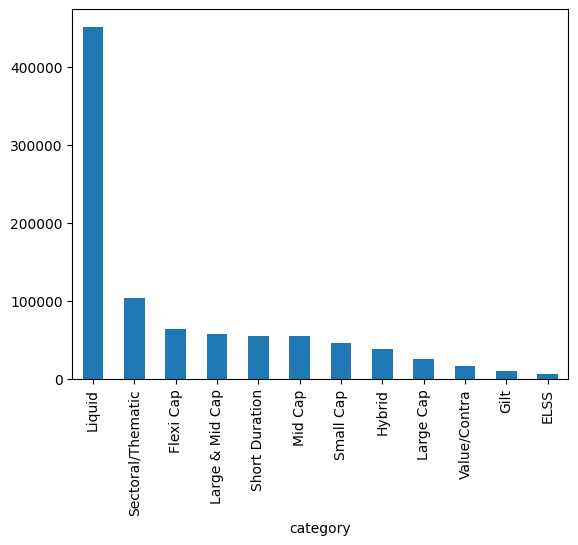

In [7]:
category = pd.read_csv(
    "../data/raw/05_category_inflows.csv"
)

cat_total = category.groupby(
    "category"
)["net_inflow_crore"].sum()

cat_total.sort_values(
    ascending=False
).plot(kind="bar")

<Axes: xlabel='state'>

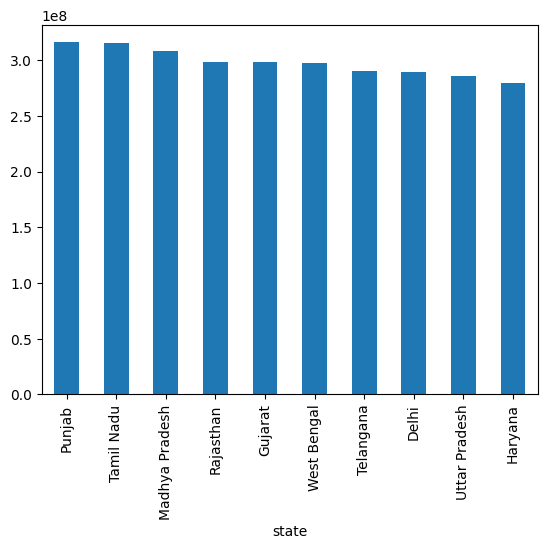

In [8]:
state_txn = transactions.groupby(
    "state"
)["amount_inr"].sum()

state_txn.sort_values(
    ascending=False
).head(10).plot(kind="bar")

<Axes: >

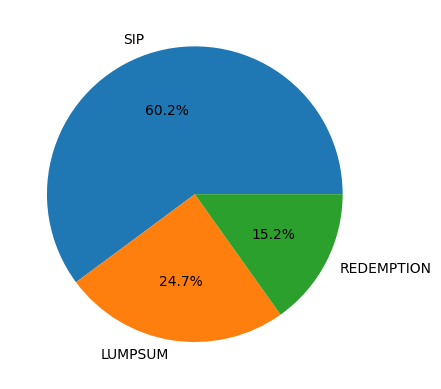

In [9]:
transactions[
    "transaction_type"
].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

<Axes: xlabel='age_group'>

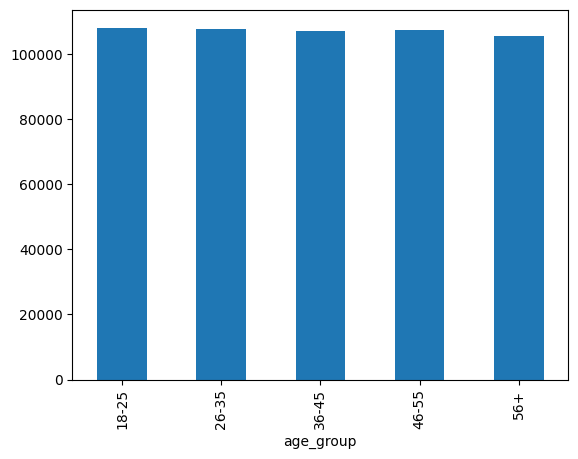

In [10]:
transactions.groupby(
    "age_group"
)["amount_inr"].mean().plot(
    kind="bar"
)

<Axes: xlabel='return_3yr_pct', ylabel='Count'>

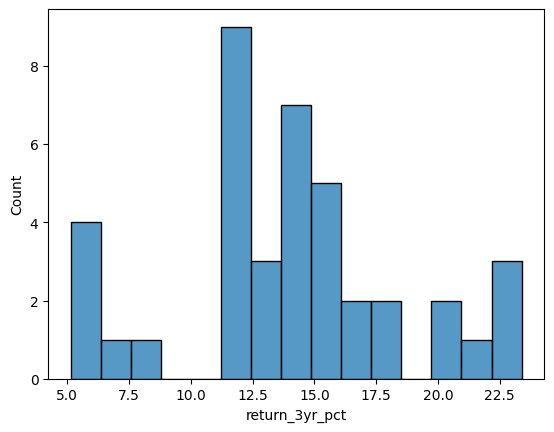

In [11]:
sns.histplot(
    performance["return_3yr_pct"],
    bins=15
)

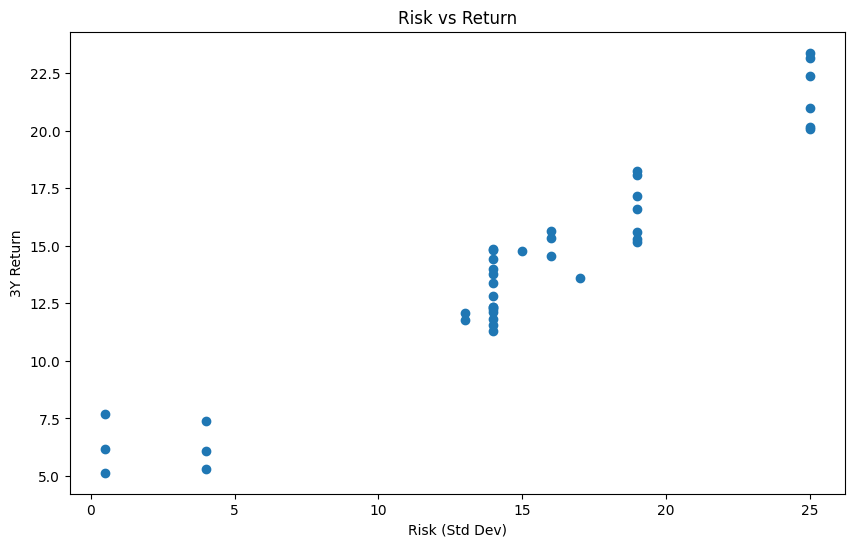

In [12]:
plt.figure(figsize=(10,6))

plt.scatter(
    performance["std_dev_ann_pct"],
    performance["return_3yr_pct"]
)

plt.xlabel("Risk (Std Dev)")
plt.ylabel("3Y Return")
plt.title("Risk vs Return")
plt.show()

<Axes: >

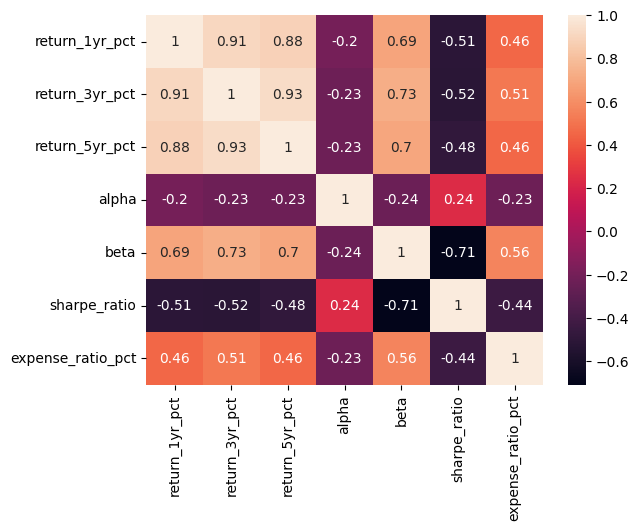

In [13]:
cols = [
    "return_1yr_pct",
    "return_3yr_pct",
    "return_5yr_pct",
    "alpha",
    "beta",
    "sharpe_ratio",
    "expense_ratio_pct"
]

sns.heatmap(
    performance[cols].corr(),
    annot=True
)